In [1]:
#create a separate script for bar plots for factor scores (worry, moodiness, and social disinterest) that are colored by domain and subdomain for plotting (keeping separate from other scripts so as to not clutter)
#load necessary packages
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

#load data - mat file and csv file
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/ICA_Results/Depression_ICA_Analyses_Clinical_Outcomes')
data = loadmat('Clinical_Outcomes_Workspace.mat')
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/clinical outcomes measures')
df = pd.read_csv("depression_cov_dx_symp_rest_conc_matched_qc_totalbrain(in)_factors.csv")


/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [5]:
# ------------------------------------------------------------
# Rerun regression results for depression-only ICA loadings
# ------------------------------------------------------------

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# Load variables from the .mat workspace
# ------------------------------------------------------------
depind = np.squeeze(data['depind']).astype(int)   # subject indices (1-based)
hcind = np.squeeze(data['hcind']).astype(int)

a = np.squeeze(data['a'])                         # ICA loadings matrix (2819 × 68)

age = data['age'].ravel()
Location_ID = data['Location_ID'].ravel()
sex_coded = data['sex_coded'].ravel()
worry_rumination = data['Worry_Rumination'].ravel()
moodiness = data['Moodiness'].ravel()
social_disinterest = data['Social_Disinterest'].ravel()

# ------------------------------------------------------------
# Clean labels (optional)
# ------------------------------------------------------------
if 'Labels' in data:
    Labels = data['Labels']
    clean_labels = [str(lbl[0]) for lbl in Labels.squeeze()]
else:
    clean_labels = None
    print("⚠️ WARNING: 'Labels' not found in .mat file")

print(clean_labels)

# ------------------------------------------------------------
# Convert MATLAB 1-based indices → Python 0-based
# ------------------------------------------------------------
depind = depind - 1

# ------------------------------------------------------------
# Extract ICA loadings for depressed subjects only
# ------------------------------------------------------------
dep_loadings = a[depind, :]   # shape: (2743 × 68)

# ------------------------------------------------------------
# Build DataFrame for regression
# ------------------------------------------------------------
df = pd.DataFrame({
    "age": age,
    "Location_ID": Location_ID,
    "sex_coded": sex_coded,
    "worry_rumination": worry_rumination,
    "moodiness": moodiness,
    "social_disinterest": social_disinterest
})

# ------------------------------------------------------------
# Add loading parameters (68 components)
# ------------------------------------------------------------
nComp = dep_loadings.shape[1]

for i in range(nComp):
    df[f"loading_{i+1}"] = dep_loadings[:, i]

print(df.head())
print("Final DataFrame shape:", df.shape)

# ------------------------------------------------------------
# Run regressions
# ------------------------------------------------------------
p_worry = []
T_worry = []
p_mood = []
T_mood = []
p_social = []
T_social = []

for i in range(68):
    loading = f"loading_{i+1}"

    formula = (
        f"{loading} ~ age + C(sex_coded) + C(Location_ID) + "
        f"worry_rumination + moodiness + social_disinterest"
    )

    model = ols(formula, data=df).fit()
    anova = sm.stats.anova_lm(model, typ=2)

    # Extract p-values
    p_worry.append(float(anova.loc["worry_rumination", "PR(>F)"]))
    p_mood.append(float(anova.loc["moodiness", "PR(>F)"]))
    p_social.append(float(anova.loc["social_disinterest", "PR(>F)"]))

    # Extract T-statistics
    T_worry.append(float(model.tvalues["worry_rumination"]))
    T_mood.append(float(model.tvalues["moodiness"]))
    T_social.append(float(model.tvalues["social_disinterest"]))

# ------------------------------------------------------------
# FDR correction
# ------------------------------------------------------------
q_worry = multipletests(p_worry, method='fdr_bh')[1]
q_mood = multipletests(p_mood, method='fdr_bh')[1]
q_social = multipletests(p_social, method='fdr_bh')[1]

# ------------------------------------------------------------
# Build results table
# ------------------------------------------------------------
results = pd.DataFrame({
    "Loading": np.arange(1, 69),
    "p_worry": p_worry,
    "q_worry": q_worry,
    "T_worry": T_worry,
    "p_mood": p_mood,
    "q_mood": q_mood,
    "T_mood": T_mood,
    "p_social": p_social,
    "q_social": q_social,
    "T_social": T_social
})

print(results)


['cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'cerebellum', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-FR', 'HC-IT', 'HC-IT', 'HC-IT', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'HC-TP', 'SC-BG', 'SC-BG', 'SC-EH', 'SC-EH', 'SC-EH', 'SC-EH', 'SC-EH', 'SC-ET', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'sensorimotor', 'TN-CE', 'TN-CE', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-DM', 'TN-SA', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OC', 'VI-OT']
   age  Location_ID  sex_coded  worry_rumination  moodiness  \
0   38           11          2          1.225029   0.467743   
1   21           10          1          0.323497   0.678197   
2   33            2          1          0.717705   1.217534   
3   54           10   

In [6]:
#build a table with significant correlations and components for each factor
# ============================================================
# Helper: significance stars
# ============================================================

def sig_star(q):
    if q < 0.01:
        return "**"
    elif q < 0.05:
        return "*"
    else:
        return ""

# ============================================================
# Add labels to results table
# ============================================================

df = results.copy()
df["Label"] = [clean_labels[i-1] for i in df["Loading"]]

# ============================================================
# Build tables for each factor (ONLY SIGNIFICANT RESULTS)
# ============================================================

def split_pos_neg_sig(df, t_col, q_col):
    """Return ONLY significant positive and negative correlations."""
    
    # Keep only significant rows
    sig_df = df[df[q_col] < 0.05].copy()
    
    # Add significance stars
    sig_df["Significance"] = sig_df[q_col].apply(sig_star)
    
    # Split by direction
    pos = sig_df[sig_df[t_col] > 0].copy()
    neg = sig_df[sig_df[t_col] < 0].copy()
    
    # Return clean tables
    return (
        pos[["Loading", "Label", t_col, q_col, "Significance"]],
        neg[["Loading", "Label", t_col, q_col, "Significance"]]
    )

# -------------------------------
# WORRY RUMINATION
# -------------------------------
worry_pos, worry_neg = split_pos_neg_sig(df, "T_worry", "q_worry")

# -------------------------------
# MOODINESS
# -------------------------------
mood_pos, mood_neg = split_pos_neg_sig(df, "T_mood", "q_mood")

# -------------------------------
# SOCIAL DISINTEREST
# -------------------------------
social_pos, social_neg = split_pos_neg_sig(df, "T_social", "q_social")

# ============================================================
# Display results
# ============================================================

print("\n=== WORRY: Positive correlations (significant only) ===")
display(worry_pos)

print("\n=== WORRY: Negative correlations (significant only) ===")
display(worry_neg)

print("\n=== MOODINESS: Positive correlations (significant only) ===")
display(mood_pos)

print("\n=== MOODINESS: Negative correlations (significant only) ===")
display(mood_neg)

print("\n=== SOCIAL DISINTEREST: Positive correlations (significant only) ===")
display(social_pos)

print("\n=== SOCIAL DISINTEREST: Negative correlations (significant only) ===")
display(social_neg)



=== WORRY: Positive correlations (significant only) ===


,Loading,Label,T_worry,q_worry,Significance
0,1,cerebellum,2.703499,0.041626,*
1,2,cerebellum,2.539376,0.044412,*
2,3,cerebellum,3.227137,0.023617,*
3,4,cerebellum,2.638961,0.043783,*
5,6,cerebellum,3.159607,0.023617,*
6,7,cerebellum,2.990192,0.031805,*
26,27,SC-BG,2.896765,0.031805,*
29,30,SC-EH,2.890287,0.031805,*
32,33,SC-EH,2.683058,0.041626,*



=== WORRY: Negative correlations (significant only) ===


,Loading,Label,T_worry,q_worry,Significance
11,12,HC-FR,-2.521326,0.044412,*
13,14,HC-FR,-2.864784,0.031805,*
14,15,HC-FR,-2.810935,0.033865,*
25,26,HC-TP,-3.135508,0.023617,*
35,36,sensorimotor,-3.788998,0.007437,**
38,39,sensorimotor,-2.547818,0.044412,*
40,41,sensorimotor,-3.702031,0.007437,**
43,44,TN-CE,-2.566268,0.044412,*
54,55,TN-SA,-2.523692,0.044412,*



=== MOODINESS: Positive correlations (significant only) ===


...

,Loading,Label,T_mood,q_mood,Significance



=== SOCIAL DISINTEREST: Positive correlations (significant only) ===


,Loading,Label,T_social,q_social,Significance
2,3,cerebellum,2.913857,0.046667,*
6,7,cerebellum,2.959872,0.046667,*
25,26,HC-TP,2.871790,0.046667,*
46,47,TN-DM,3.069052,0.046667,*
67,68,VI-OT,3.114000,0.046667,*



=== SOCIAL DISINTEREST: Negative correlations (significant only) ===


,Loading,Label,T_social,q_social,Significance
54,55,TN-SA,-3.850604,0.008224,**


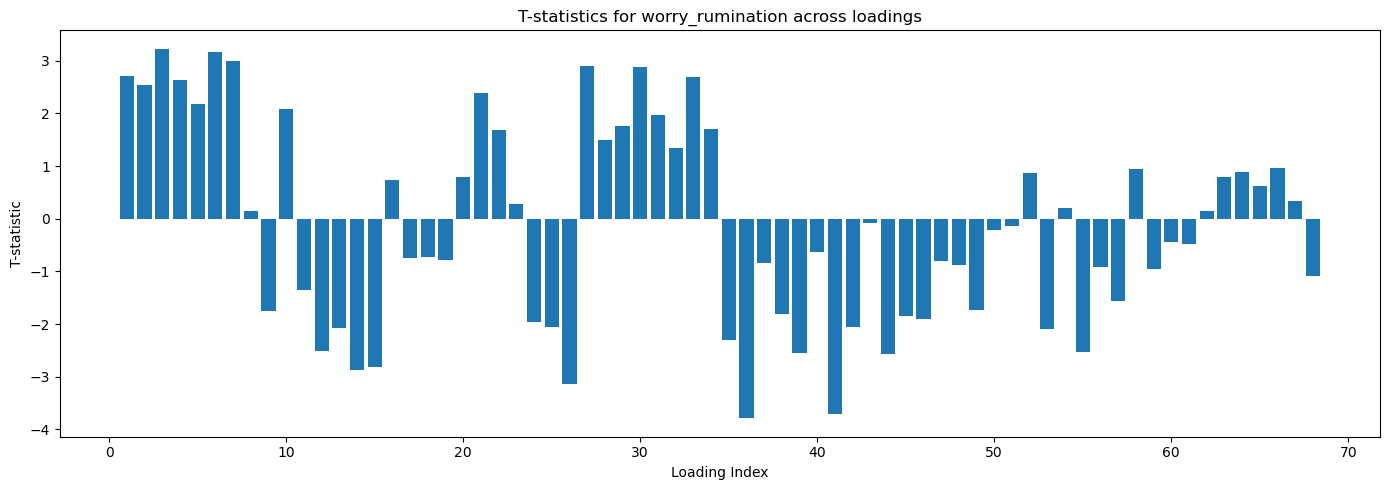

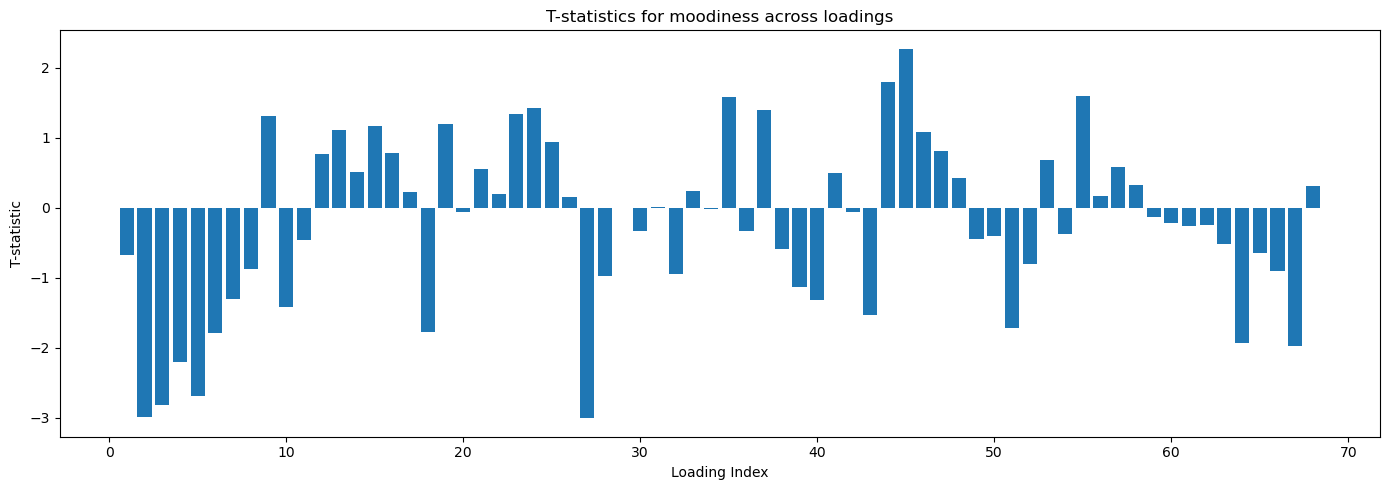

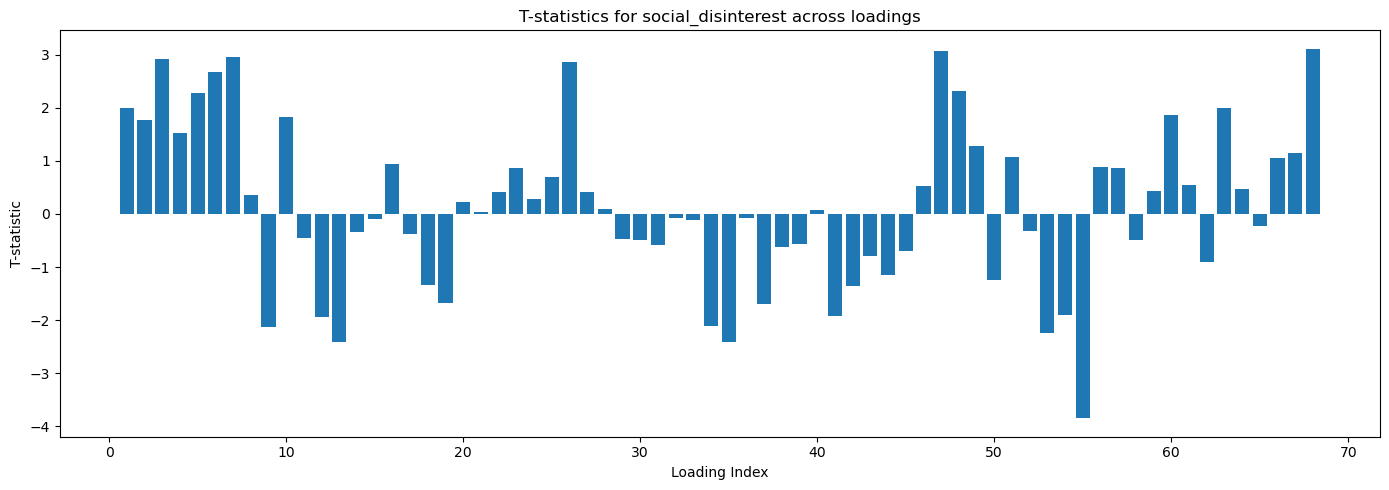

In [7]:
#load original t-stat plots for sanity check for worry, moodiness, and social disinterest

# --- T-STAT PLOT (worry) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_worry"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for worry_rumination across loadings")
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (moodiness) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_mood"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for moodiness across loadings")
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (social_disinterest) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_social"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for social_disinterest across loadings")
plt.tight_layout()
plt.show()

/var/folders/2r/lcd0_jwn383gpby4x6q6v5100000gn/T/ipykernel_28750/3860546082.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_cats))


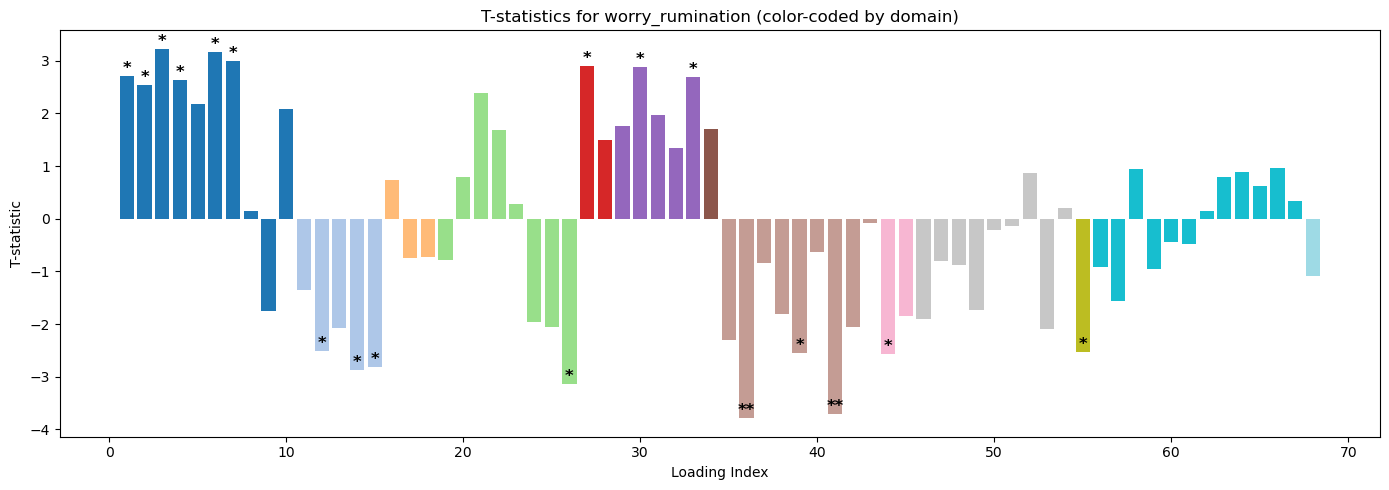

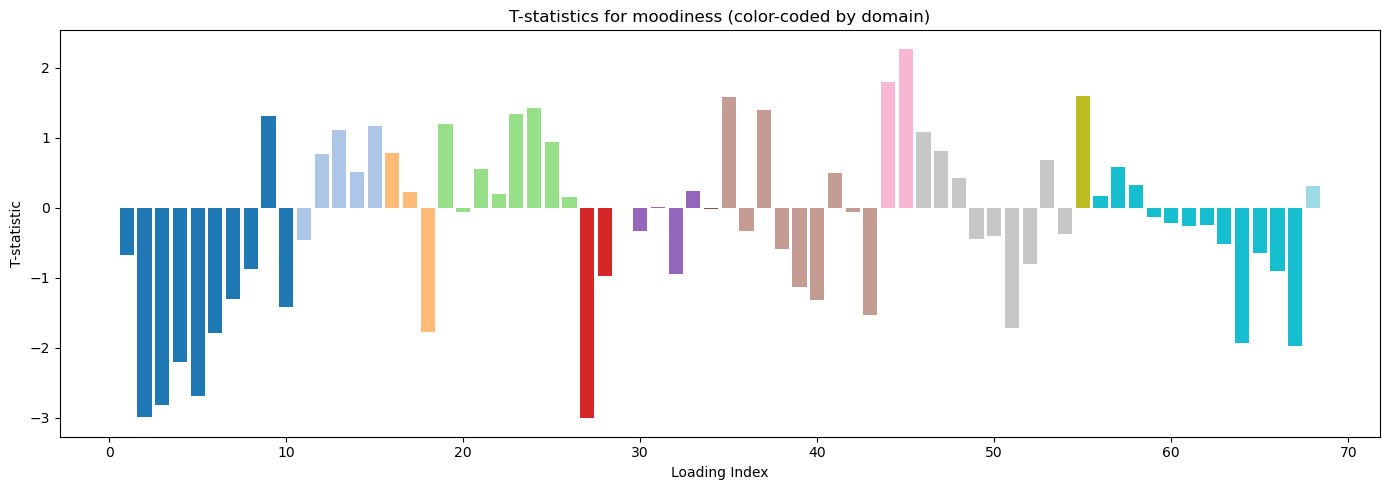

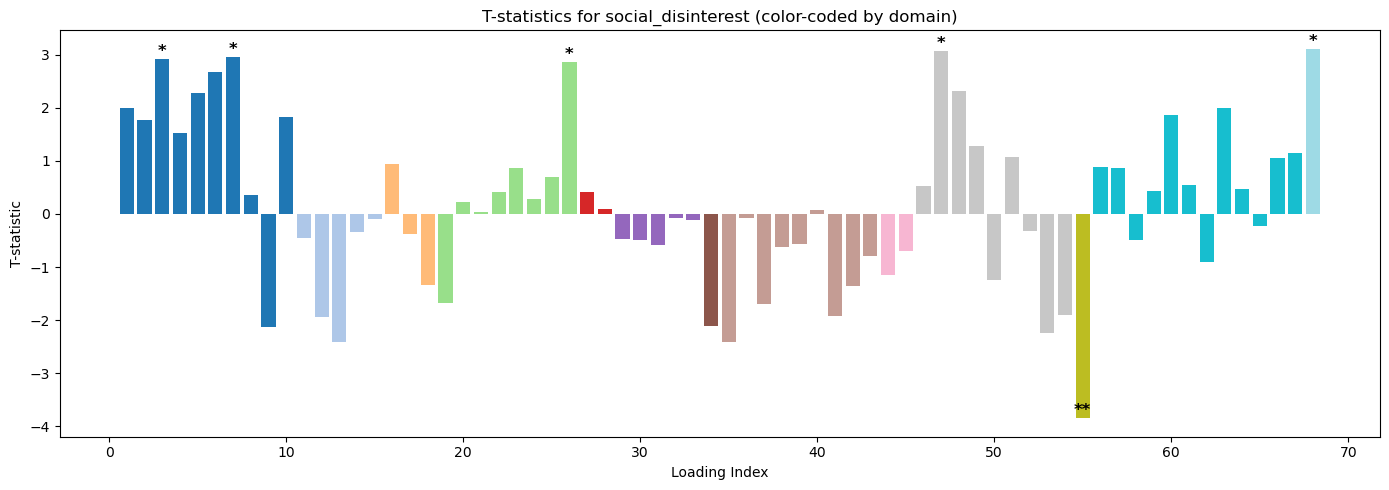

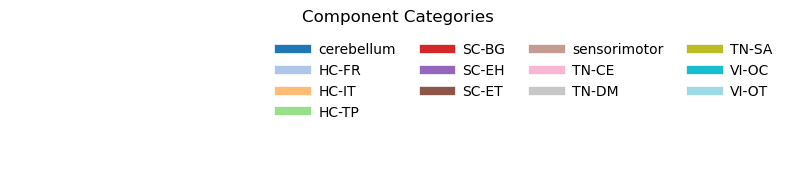

In [8]:
# now modify these to be colored by domain and subdomain

import matplotlib.cm as cm

# Unique categories from clean_labels (preserves order)
unique_cats = list(dict.fromkeys(clean_labels))

# Assign each category a color
cmap = cm.get_cmap("tab20", len(unique_cats))
category_to_color = {cat: cmap(i) for i, cat in enumerate(unique_cats)}

# Helper: get color for each component number
def get_colors(loadings):
    return [category_to_color[clean_labels[i-1]] for i in loadings]

# Helper: get significance stars
def get_sig_stars(q):
    if q < 0.01:
        return "**"
    elif q < 0.05:
        return "*"
    else:
        return ""

# --- FIX: use the correct DataFrame which is results ---
df_plot = results

# -------------------------------
# T-STAT PLOT (worry)
# -------------------------------
plt.figure(figsize=(14, 5))
loadings = df_plot["Loading"].astype(int).tolist()
colors = get_colors(loadings)

bars = plt.bar(
    df_plot["Loading"],
    df_plot["T_worry"],
    color=colors
)

# Add significance stars
for bar, q in zip(bars, df_plot["q_worry"]):
    star = get_sig_stars(q)
    if star:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            star,
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for worry_rumination (color-coded by domain)")
plt.tight_layout()
plt.show()

# -------------------------------
# T-STAT PLOT (moodiness)
# -------------------------------
plt.figure(figsize=(14, 5))
colors = get_colors(loadings)

bars = plt.bar(
    df_plot["Loading"],
    df_plot["T_mood"],
    color=colors
)

for bar, q in zip(bars, df_plot["q_mood"]):
    star = get_sig_stars(q)
    if star:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            star,
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for moodiness (color-coded by domain)")
plt.tight_layout()
plt.show()

# -------------------------------
# T-STAT PLOT (social_disinterest)
# -------------------------------
plt.figure(figsize=(14, 5))
colors = get_colors(loadings)

bars = plt.bar(
    df_plot["Loading"],
    df_plot["T_social"],
    color=colors
)

for bar, q in zip(bars, df_plot["q_social"]):
    star = get_sig_stars(q)
    if star:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            star,
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold'
        )

plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for social_disinterest (color-coded by domain)")
plt.tight_layout()
plt.show()

# -------------------------------
# Legend for categories
# -------------------------------
legend_handles = [
    plt.Line2D([0], [0], color=category_to_color[cat], lw=6, label=cat)
    for cat in unique_cats
]

plt.figure(figsize=(10, 2))
plt.legend(handles=legend_handles, ncol=4, frameon=False)
plt.axis("off")
plt.title("Component Categories")
plt.show()


/var/folders/2r/lcd0_jwn383gpby4x6q6v5100000gn/T/ipykernel_28750/1696930042.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(unique_cats))


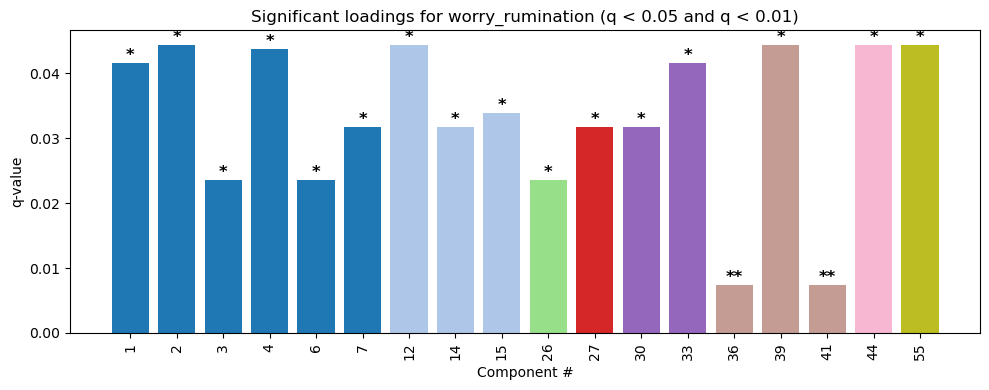

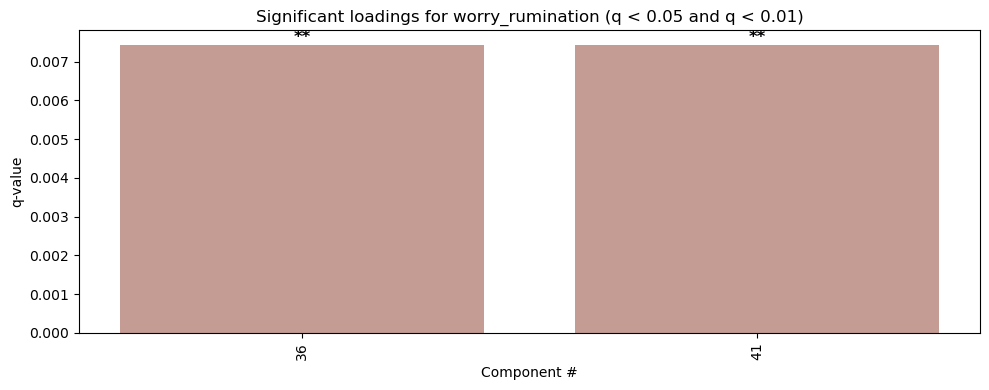

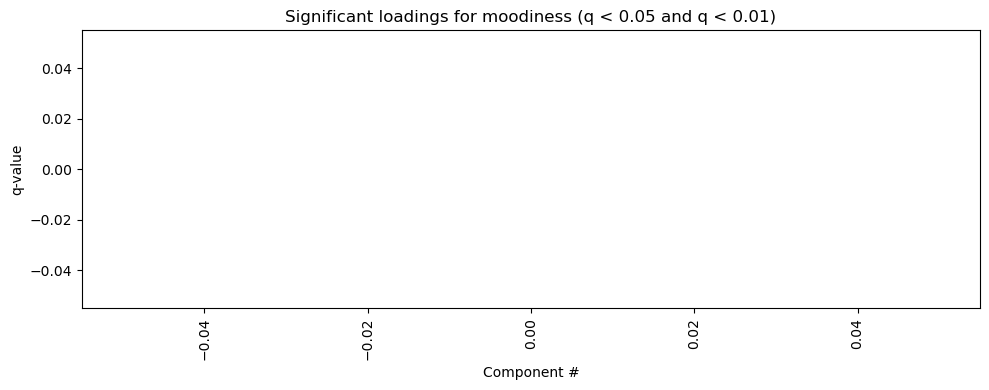

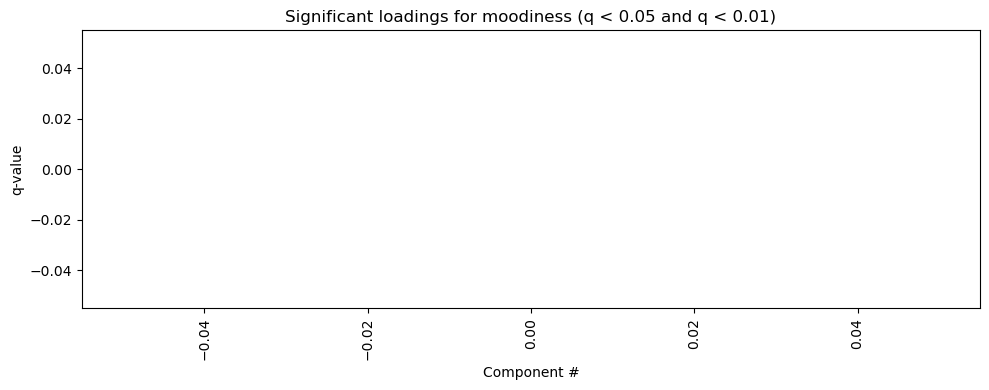

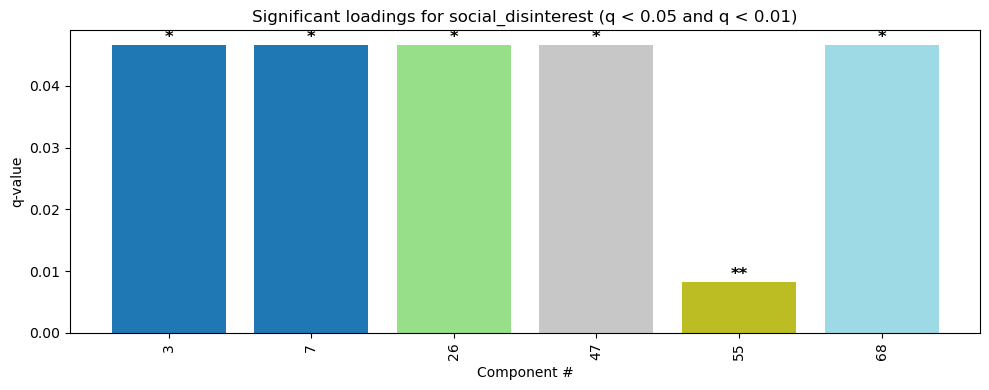

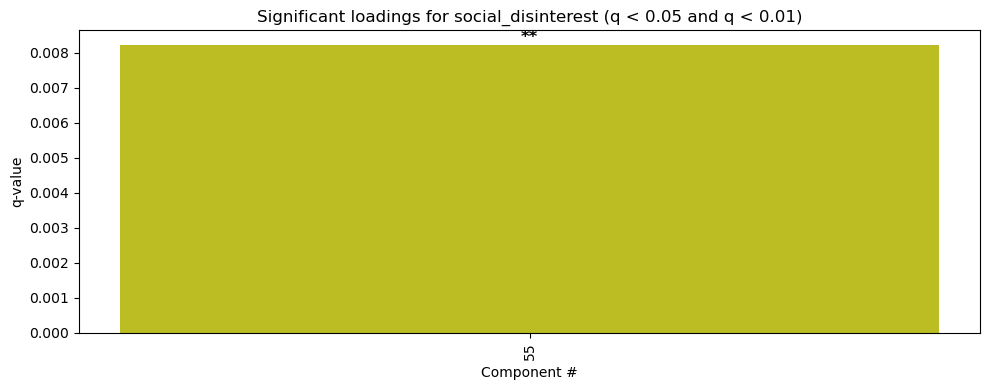

In [9]:
# ============================================================
# 1. Build category → color map from clean_labels
# ============================================================

import matplotlib.cm as cm

# Unique categories from clean_labels (preserves order)
unique_cats = list(dict.fromkeys(clean_labels))

# Assign each category a color
cmap = cm.get_cmap("tab20", len(unique_cats))
category_to_color = {cat: cmap(i) for i, cat in enumerate(unique_cats)}

# Helper: get color for each component number
def get_colors(loadings):
    return [category_to_color[clean_labels[i-1]] for i in loadings]

# Helper: significance stars
def get_sig_stars(q):
    if q < 0.01:
        return "**"
    elif q < 0.05:
        return "*"
    else:
        return ""

# ============================================================
# 2. Use df = results
# ============================================================

df_plot = results


# ============================================================
# 3. WORRY RUMINATION — q < 0.05 and q < 0.01
# ============================================================

# --- q < 0.05 ---
sig = df_plot[df_plot["q_worry"] < 0.05]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
bars = plt.bar([str(i) for i in sig_loadings], sig["q_worry"], color=sig_colors)

# Add stars
for bar, q in zip(bars, sig["q_worry"]):
    star = get_sig_stars(q)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 star,
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.05 and q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


# --- q < 0.01 ---
sig = df_plot[df_plot["q_worry"] < 0.01]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
bars = plt.bar([str(i) for i in sig_loadings], sig["q_worry"], color=sig_colors)

for bar, q in zip(bars, sig["q_worry"]):
    star = get_sig_stars(q)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 star,
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.05 and q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


# ============================================================
# 4. MOODINESS — q < 0.05 and q < 0.01
# ============================================================

# --- q < 0.05 ---
sig = df_plot[df_plot["q_mood"] < 0.05]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
bars = plt.bar([str(i) for i in sig_loadings], sig["q_mood"], color=sig_colors)

for bar, q in zip(bars, sig["q_mood"]):
    star = get_sig_stars(q)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 star,
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.05 and q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


# --- q < 0.01 ---
sig = df_plot[df_plot["q_mood"] < 0.01]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
bars = plt.bar([str(i) for i in sig_loadings], sig["q_mood"], color=sig_colors)

for bar, q in zip(bars, sig["q_mood"]):
    star = get_sig_stars(q)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 star,
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.05 and q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


# ============================================================
# 5. SOCIAL DISINTEREST — q < 0.05 and q < 0.01
# ============================================================

# --- q < 0.05 ---
sig = df_plot[df_plot["q_social"] < 0.05]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
bars = plt.bar([str(i) for i in sig_loadings], sig["q_social"], color=sig_colors)

for bar, q in zip(bars, sig["q_social"]):
    star = get_sig_stars(q)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 star,
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.05 and q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


# --- q < 0.01 ---
sig = df_plot[df_plot["q_social"] < 0.01]
sig_loadings = sig["Loading"].astype(int).tolist()
sig_colors = get_colors(sig_loadings)

plt.figure(figsize=(10, 4))
bars = plt.bar([str(i) for i in sig_loadings], sig["q_social"], color=sig_colors)

for bar, q in zip(bars, sig["q_social"]):
    star = get_sig_stars(q)
    if star:
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height(),
                 star,
                 ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.05 and q < 0.01)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()
